# TECH 405 – Week 5 RNN Hackathon

## SMS Spam Classification Using LSTM

**Dataset:** SMS Spam  
**Task:** Binary text classification — spam vs ham  
**Baseline Accuracy:** 86.6%  
**Target Accuracy:** 96%

Each SMS message is treated as an ordered sequence of words.

The model follows the required lecture architecture:

**Embedding → `nn.LSTM` → `nn.Linear`**

No pretrained model is used.


## 1. Import Libraries


In [1]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from collections import Counter

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Using device: cpu


## 2. Download and Load the SMS Spam Dataset

The dataset contains SMS messages labeled as either **ham** or **spam**. The assignment baseline is 86.6% and the target accuracy is 96%.


In [2]:
url = "https://raw.githubusercontent.com/mohitgupta-omg/Kaggle-SMS-Spam-Collection-Dataset-/master/spam.csv"

df = pd.read_csv(url, encoding="latin-1")[["v1", "v2"]]
df.columns = ["label", "text"]

print(df.head())
print("\nDataset shape:", df.shape)
print("\nClass counts:")
print(df["label"].value_counts())


  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Dataset shape: (5572, 2)

Class counts:
label
ham     4825
spam     747
Name: count, dtype: int64


## 3. Why This Is a Sequence Problem

SMS messages are sequential because word order affects meaning. The LSTM reads the tokens in order and learns patterns associated with spam and normal messages.


In [3]:
print("Number of samples:", len(df))
print("Number of classes:", df["label"].nunique())
print("Classes:", df["label"].unique())

print("\nExample message:")
print(df.iloc[0]["text"])
print("Label:", df.iloc[0]["label"])


Number of samples: 5572
Number of classes: 2
Classes: <StringArray>
['ham', 'spam']
Length: 2, dtype: str

Example message:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Label: ham


**Figure 1 – Dataset and shape information (Snapshot 1):**  
The SMS Spam dataset contains labeled text messages from two classes: ham and spam. Each message is converted into a fixed-length sequence before being passed to the LSTM.


## 4. Clean the Text


In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

print(df[["text", "clean_text"]].head())


                                                text  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                          clean_text  
0  go until jurong point crazy available only in ...  
1                            ok lar joking wif u oni  
2  free entry in 2 a wkly comp to win fa cup fina...  
3        u dun say so early hor u c already then say  
4  nah i don t think he goes to usf he lives arou...  


## 5. Convert Labels to Numbers


In [5]:
label_map = {"ham": 0, "spam": 1}
df["target"] = df["label"].map(label_map)

print(df[["label", "target"]].head())


  label  target
0   ham       0
1   ham       0
2  spam       1
3   ham       0
4   ham       0


## 6. Fixed 80/20 Train-Test Split

A fixed split is created with `random_state=42`. The test set is kept untouched during model development.


In [6]:
train_texts, test_texts, y_train, y_test = train_test_split(
    df["clean_text"].values,
    df["target"].values,
    test_size=0.20,
    random_state=42,
    stratify=df["target"].values
)

print("Training samples:", len(train_texts))
print("Test samples:", len(test_texts))


Training samples: 4457
Test samples: 1115


## 7. Create a Validation Set


In [7]:
train_texts, val_texts, y_train, y_val = train_test_split(
    train_texts,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Final training samples:", len(train_texts))
print("Validation samples:", len(val_texts))
print("Untouched test samples:", len(test_texts))


Final training samples: 3565
Validation samples: 892
Untouched test samples: 1115


## 8. Build the Vocabulary

The vocabulary is built from the training text only to avoid leaking information from the validation or test sets.


In [8]:
def tokenize(text):
    return text.split()

counter = Counter()
for text in train_texts:
    counter.update(tokenize(text))

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"

vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}

for word, count in counter.most_common(8000):
    if word not in vocab:
        vocab[word] = len(vocab)

print("Vocabulary size:", len(vocab))
print(list(vocab.items())[:20])


Vocabulary size: 6765
[('<pad>', 0), ('<unk>', 1), ('i', 2), ('you', 3), ('to', 4), ('a', 5), ('the', 6), ('u', 7), ('and', 8), ('in', 9), ('is', 10), ('me', 11), ('my', 12), ('it', 13), ('for', 14), ('your', 15), ('call', 16), ('of', 17), ('have', 18), ('that', 19)]


## 9. Encode and Pad the Messages

Each message is converted to word IDs and padded or truncated to a maximum length of 50 words.


In [9]:
MAXLEN = 50

def encode_text(text):
    tokens = tokenize(text)
    ids = [vocab.get(token, vocab[UNK_TOKEN]) for token in tokens]
    ids = ids[:MAXLEN]

    if len(ids) < MAXLEN:
        ids += [vocab[PAD_TOKEN]] * (MAXLEN - len(ids))

    return ids

X_train = np.array([encode_text(t) for t in train_texts])
X_val = np.array([encode_text(t) for t in val_texts])
X_test = np.array([encode_text(t) for t in test_texts])

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Training shape: (3565, 50)
Validation shape: (892, 50)
Test shape: (1115, 50)


## 10. Convert to PyTorch Tensors


In [10]:
X_train_tensor = torch.tensor(X_train, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


## 11. Create DataLoaders


In [11]:
BATCH_SIZE = 32

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False
)


## 12. Define the LSTM Model

The model uses an embedding layer, an LSTM, and a linear output layer with two outputs for ham and spam.


In [12]:
class SpamLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_size=128, num_classes=2):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        output, (hidden, cell) = self.lstm(x)
        return self.fc(hidden[-1])

model = SpamLSTM(vocab_size=len(vocab)).to(device)

print(model)


SpamLSTM(
  (embedding): Embedding(6765, 64, padding_idx=0)
  (lstm): LSTM(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


**Figure 2 – LSTM model definition (Snapshot 2):**  
The model converts word IDs into 64-dimensional embeddings, processes them with an LSTM containing 128 hidden units, and classifies each message using a linear layer with two outputs.


## 13. Loss Function and Optimizer


In [13]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


## 14. Train the Model


In [14]:
EPOCHS = 12

train_losses = []
val_accuracies = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            predictions = outputs.argmax(dim=1)

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    val_accuracy = correct / total
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss: {avg_loss:.4f} | "
        f"Validation Accuracy: {val_accuracy*100:.2f}%"
    )


Epoch 1/12 | Loss: 0.3716 | Validation Accuracy: 91.48%
Epoch 2/12 | Loss: 0.1612 | Validation Accuracy: 88.57%
Epoch 3/12 | Loss: 0.2027 | Validation Accuracy: 91.26%
Epoch 4/12 | Loss: 0.1391 | Validation Accuracy: 94.84%
Epoch 5/12 | Loss: 0.0697 | Validation Accuracy: 96.08%
Epoch 6/12 | Loss: 0.0586 | Validation Accuracy: 95.18%
Epoch 7/12 | Loss: 0.0631 | Validation Accuracy: 96.30%
Epoch 8/12 | Loss: 0.0493 | Validation Accuracy: 96.75%
Epoch 9/12 | Loss: 0.0675 | Validation Accuracy: 96.97%
Epoch 10/12 | Loss: 0.0393 | Validation Accuracy: 97.31%
Epoch 11/12 | Loss: 0.0604 | Validation Accuracy: 96.97%
Epoch 12/12 | Loss: 0.0361 | Validation Accuracy: 97.65%


## 15. Training Loss Plot


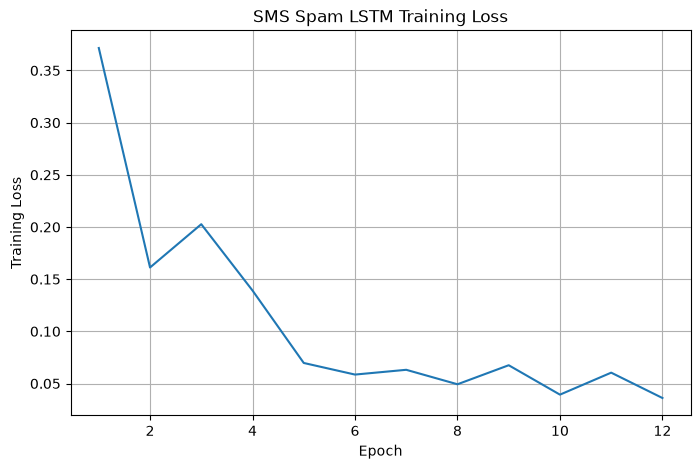

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("SMS Spam LSTM Training Loss")
plt.grid(True)
plt.show()


**Figure 3 – Training loss (Snapshot 3):**  
A general downward trend indicates that the LSTM is learning useful patterns from the SMS sequences and reducing classification error.


## 16. Validation Accuracy


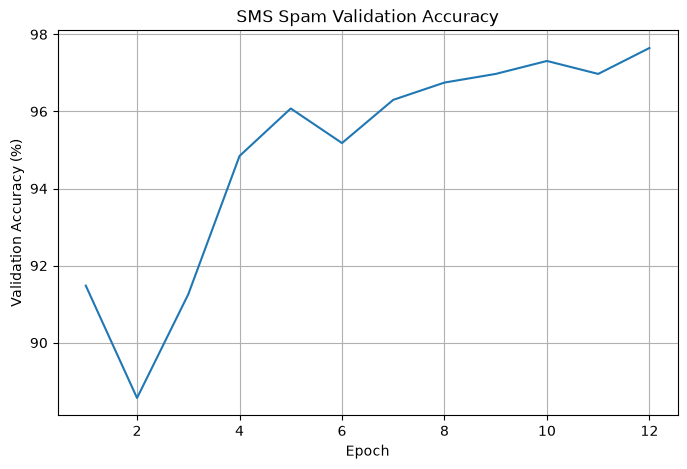

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), np.array(val_accuracies) * 100)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("SMS Spam Validation Accuracy")
plt.grid(True)
plt.show()


## 17. Hyperparameter Experiments

Three configurations are compared using **validation accuracy only**. The test set is not used during this comparison.


In [17]:
class ExperimentSpamLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_size=64):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 2)

    def forward(self, x):
        x = self.embedding(x)
        output, (hidden, cell) = self.lstm(x)
        return self.fc(hidden[-1])


def run_experiment(hidden_size, embedding_dim=64, lr=0.001, epochs=6):
    torch.manual_seed(42)

    exp_model = ExperimentSpamLSTM(
        vocab_size=len(vocab),
        embedding_dim=embedding_dim,
        hidden_size=hidden_size
    ).to(device)

    exp_optimizer = torch.optim.Adam(exp_model.parameters(), lr=lr)
    exp_criterion = nn.CrossEntropyLoss()

    best_val_accuracy = 0.0

    for epoch in range(epochs):
        exp_model.train()

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            exp_optimizer.zero_grad()
            outputs = exp_model(X_batch)
            loss = exp_criterion(outputs, y_batch)
            loss.backward()
            exp_optimizer.step()

        exp_model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = exp_model(X_batch)
                predictions = outputs.argmax(dim=1)

                correct += (predictions == y_batch).sum().item()
                total += y_batch.size(0)

        val_accuracy = correct / total
        best_val_accuracy = max(best_val_accuracy, val_accuracy)

    return best_val_accuracy * 100


experiment_settings = [
    {"hidden_size": 64,  "embedding_dim": 32, "lr": 0.001},
    {"hidden_size": 128, "embedding_dim": 64, "lr": 0.001},
    {"hidden_size": 128, "embedding_dim": 64, "lr": 0.0005},
]

for i, config in enumerate(experiment_settings, start=1):
    best_val = run_experiment(**config)

    print(
        f"Experiment {i}: "
        f"hidden={config['hidden_size']}, "
        f"embedding={config['embedding_dim']}, "
        f"lr={config['lr']} -> "
        f"Best Validation Accuracy = {best_val:.2f}%"
    )


Experiment 1: hidden=64, embedding=32, lr=0.001 -> Best Validation Accuracy = 95.40%
Experiment 2: hidden=128, embedding=64, lr=0.001 -> Best Validation Accuracy = 96.08%
Experiment 3: hidden=128, embedding=64, lr=0.0005 -> Best Validation Accuracy = 96.30%


## 18. Final Test Evaluation


In [18]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

test_accuracy = accuracy_score(all_labels, all_predictions)

print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")


Final Test Accuracy: 97.13%


## 19. Confusion Matrix


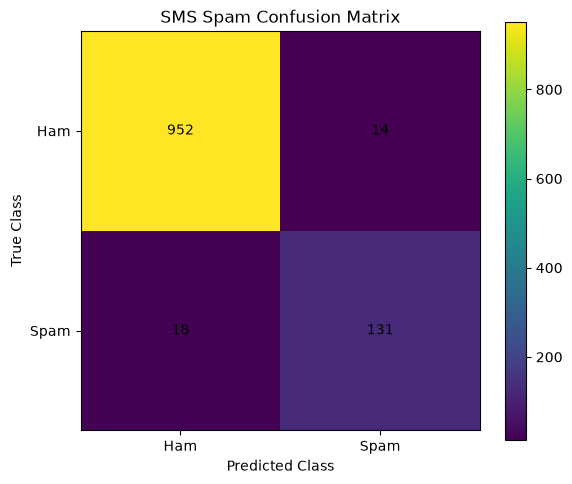

In [19]:
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("SMS Spam Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.colorbar()

plt.xticks([0, 1], ["Ham", "Spam"])
plt.yticks([0, 1], ["Ham", "Spam"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


## 20. Precision, Recall and F1-score


In [20]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["Ham", "Spam"],
        digits=4
    )
)


              precision    recall  f1-score   support

         Ham     0.9814    0.9855    0.9835       966
        Spam     0.9034    0.8792    0.8912       149

    accuracy                         0.9713      1115
   macro avg     0.9424    0.9324    0.9373      1115
weighted avg     0.9710    0.9713    0.9711      1115



## 21. Baseline, Target and Final Accuracy

For SMS Spam:

- **Baseline:** 86.6%
- **Target:** 96%


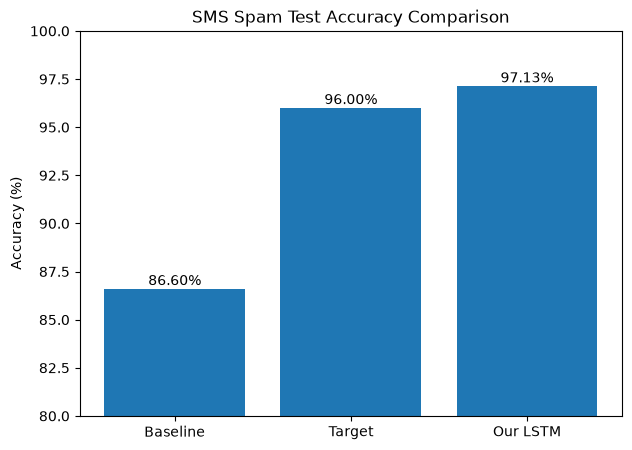

Baseline Accuracy: 86.6%
Target Accuracy: 96%
Our Test Accuracy: 97.13%


In [21]:
baseline = 86.6
target = 96
our_accuracy = test_accuracy * 100

names = ["Baseline", "Target", "Our LSTM"]
scores = [baseline, target, our_accuracy]

plt.figure(figsize=(7, 5))
plt.bar(names, scores)
plt.ylabel("Accuracy (%)")
plt.title("SMS Spam Test Accuracy Comparison")
plt.ylim(80, 100)

for i, score in enumerate(scores):
    plt.text(i, score + 0.2, f"{score:.2f}%", ha="center")

plt.show()

print(f"Baseline Accuracy: {baseline}%")
print(f"Target Accuracy: {target}%")
print(f"Our Test Accuracy: {our_accuracy:.2f}%")


**Figure 4 – Final test accuracy comparison (Snapshot 4):**  
The graph compares the **86.6% majority-class baseline**, the **96% assignment target**, and the final test accuracy achieved by the LSTM.
